# Perfiles NFW con retroacción del halo: resultados de results/NFW_test_1200

Se muestran los resultados individuales, su comparación conjunta y el perfil analítico final de ley de potencia para $\gamma=1$. Se añaden el perfil convergido con su pendiente local y el cambio relativo entre iteraciones consecutivas hasta la convergencia. Los radios están en pc y las densidades en $M_\odot/\mathrm{pc}^3$.

Los ejes de los perfiles muestran $\log_{10}(r/R_S)$ y $\log_{10}[\rho^\prime/(M_\odot\,\mathrm{pc}^{-3})]$, donde $R_S$ es el radio de Schwarzschild.

El último gráfico compara el resultado convergido con el NFW inicial y con la ley de potencia final de $\gamma=1$.

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np

# El notebook vive en la raíz del repositorio; también funciona si el kernel
# se inicia desde una subcarpeta del proyecto.
ROOT = next(
    (p for p in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
     if (p / 'results' / 'NFW_test_1200').is_dir() and (p / 'src' / 'dm_spikes').is_dir()),
    None,
)
if ROOT is None:
    raise FileNotFoundError('No se encontró la raíz del repositorio con results/NFW_test_1200.')
sys.path.insert(0, str(ROOT / 'src'))

from dm_spikes.density_models import nfw, power_law
from dm_spikes.final_profile import schwarzschild_radius
from dm_spikes.power_law_profile import D, rho_D, cusp_profile, gamma_spike, spike_radius

results_dir = ROOT / 'results' / 'NFW_test_1200'
result_files = sorted(results_dir.glob('*.npz'))
if not result_files:
    raise FileNotFoundError(f'No hay archivos NPZ en {results_dir}')

records = []
for path in result_files:
    with np.load(path, allow_pickle=False) as data:
        radii = np.asarray(data['radii'], dtype=float).copy()
        density = np.asarray(data['rho_prime'], dtype=float).copy()
        config = json.loads(data['config_json'].item())
        is_final = 'iterations' in data.files
        iteration = int(data['iterations' if is_final else 'iteration'].item())
        converged = bool(data['converged'].item())
    if radii.ndim != 1 or radii.shape != density.shape:
        raise ValueError(f'Malla y densidad incompatibles: {path.name}')
    if not (np.all(np.isfinite(radii)) and np.all(np.isfinite(density))
            and np.all(radii > 0) and np.all(density > 0)):
        raise ValueError(f'Los ejes logarítmicos requieren datos finitos y positivos: {path.name}')
    label = f'Final ({iteration} iteraciones)' if is_final else f'Iteración {iteration:03d}'
    records.append(dict(path=path, radii=radii, density=density, config=config,
                        is_final=is_final, iteration=iteration,
                        converged=converged, label=label))
records.sort(key=lambda rec: (rec['is_final'], rec['iteration'], rec['path'].name))

reference = next(rec for rec in records if rec['is_final'])['config']
R_S = schwarzschild_radius(reference['M_bh'], clight=reference['clight'])

# Mismo limite visible que el grafico de densidades de perfiles_analiticos.ipynb:
# 4.0001 R_S hasta el mayor R_sp de gamma=0.01,...,1.99, con margen del 5 %.
reference_gammas = np.arange(0.01, 2.00, 0.01)
reference_rsp = spike_radius(reference['M_bh'], reference_gammas,
                             rho_D(reference_gammas), D)
reference_x_start = np.log10(4.0001)
reference_x_end = np.log10(np.max(reference_rsp) / R_S)
reference_x_left = reference_x_start - 0.05 * (reference_x_end - reference_x_start)

r_min = min(rec['radii'].min() for rec in records)
r_max = max(rec['radii'].max() for rec in records)
rho_min = min(rec['density'].min() for rec in records)
rho_max = max(rec['density'].max() for rec in records)

def format_axes(ax, title):
    ax.set(xlim=(reference_x_left, np.log10(r_max / R_S)),
           ylim=(np.log10(rho_min / 2), np.log10(rho_max * 2)),
           title=title,
           xlabel=r'$\log_{10}(r/R_S)$',
           ylabel=r'$\log_{10}[\rho^\prime(r)/(M_\odot\,\mathrm{pc}^{-3})]$')
    ax.grid(True, alpha=0.25)

print(f'{len(records)} resultados cargados desde {results_dir}')
print(', '.join(rec['path'].name for rec in records))

def add_profile_zoom(ax):
    """Amplía en un recuadro las mismas curvas y estilos del gráfico principal."""
    x_left, x_right = 7.9, 8.0
    zoom_ax = ax.inset_axes((0.075, 0.08, 0.43, 0.38))
    visible_y = []
    for line in ax.get_lines():
        x = np.asarray(line.get_xdata(), dtype=float)
        y = np.asarray(line.get_ydata(), dtype=float)
        selected = (x >= x_left) & (x <= x_right) & np.isfinite(x) & np.isfinite(y)
        if np.count_nonzero(selected) < 2:
            continue
        visible_y.append(y[selected])
        zoom_ax.plot(x, y, color=line.get_color(), linestyle=line.get_linestyle(),
                     linewidth=line.get_linewidth(), alpha=line.get_alpha(),
                     marker=line.get_marker(), markersize=line.get_markersize(),
                     markevery=line.get_markevery(), zorder=line.get_zorder())
    if not visible_y:
        raise ValueError('No hay puntos en la región elegida para el zoom.')
    y_zoom = np.concatenate(visible_y)
    y_padding = 0.07 * (y_zoom.max() - y_zoom.min())
    zoom_ax.set(xlim=(x_left, x_right),
                ylim=(y_zoom.min() - y_padding, y_zoom.max() + y_padding))
    zoom_ax.set_xticks([7.9, 7.95, 8.0])
    zoom_ax.tick_params(labelsize=8)
    zoom_ax.grid(True, alpha=0.25)
    zoom_ax.set_facecolor('white')
    zoom_ax.set_zorder(20)
    ax.indicate_inset_zoom(zoom_ax, edgecolor='0.35')
    return zoom_ax

9 resultados cargados desde C:\Users\luisa\Documents\Repo GitHub\DM-spikes\results\NFW_test_1200
nfw_380mpc_iter_001.npz, nfw_380mpc_iter_002.npz, nfw_380mpc_iter_003.npz, nfw_380mpc_iter_004.npz, nfw_380mpc_iter_005.npz, nfw_380mpc_iter_006.npz, nfw_380mpc_iter_007.npz, nfw_380mpc_iter_008.npz, nfw_380mpc.npz


## Cada resultado por separado

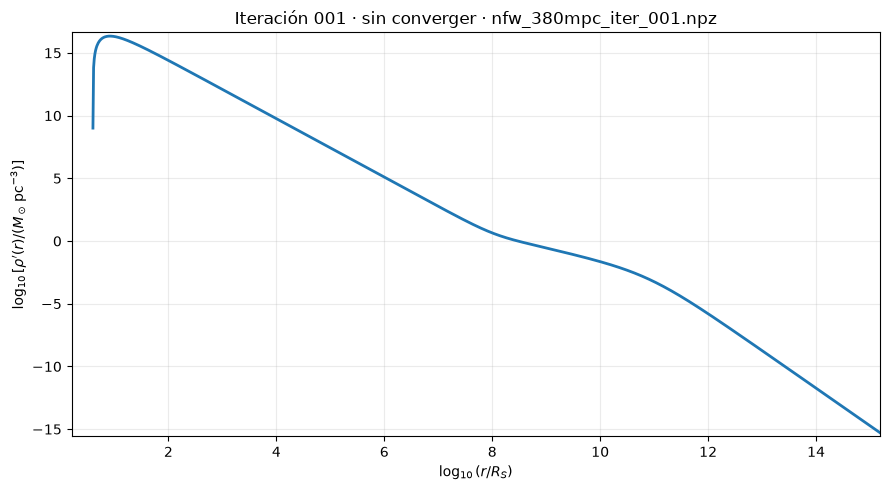

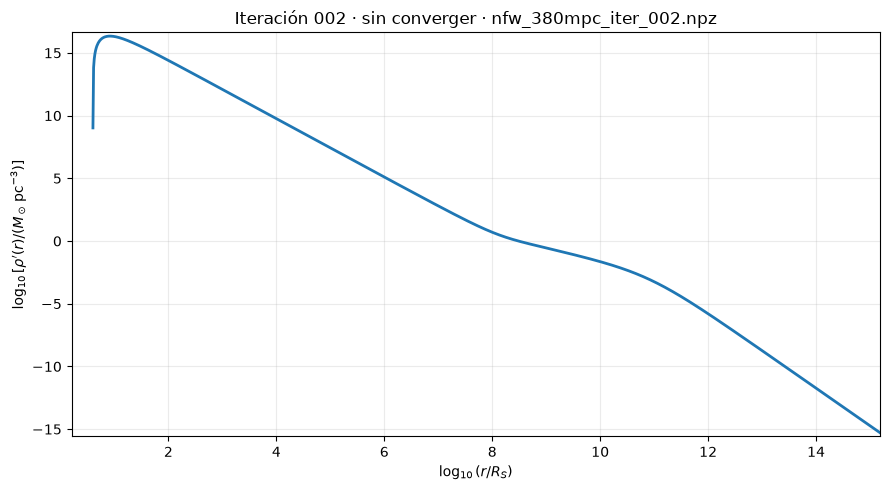

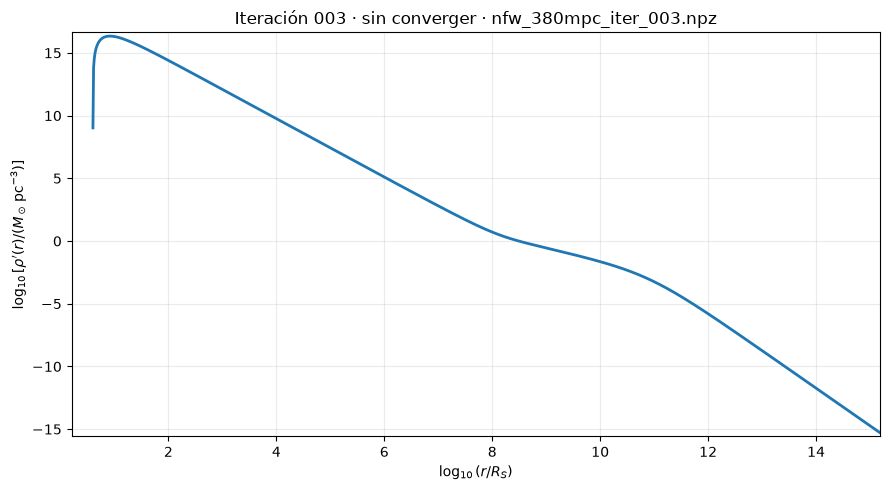

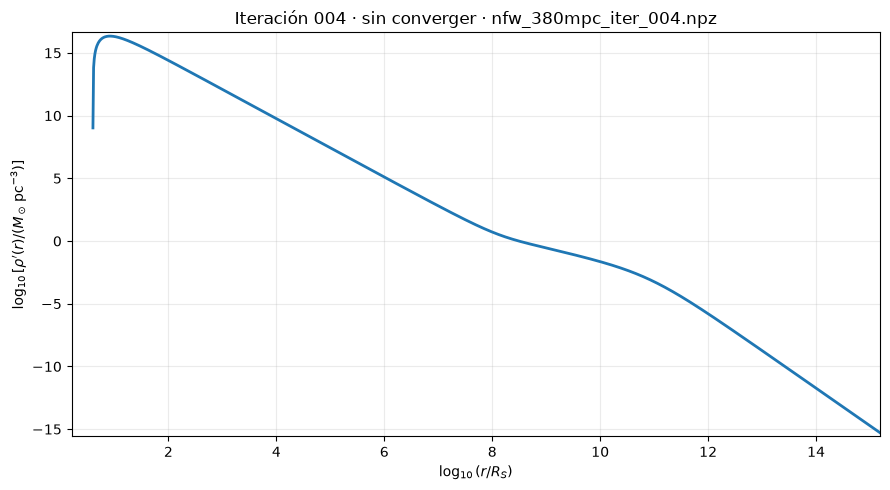

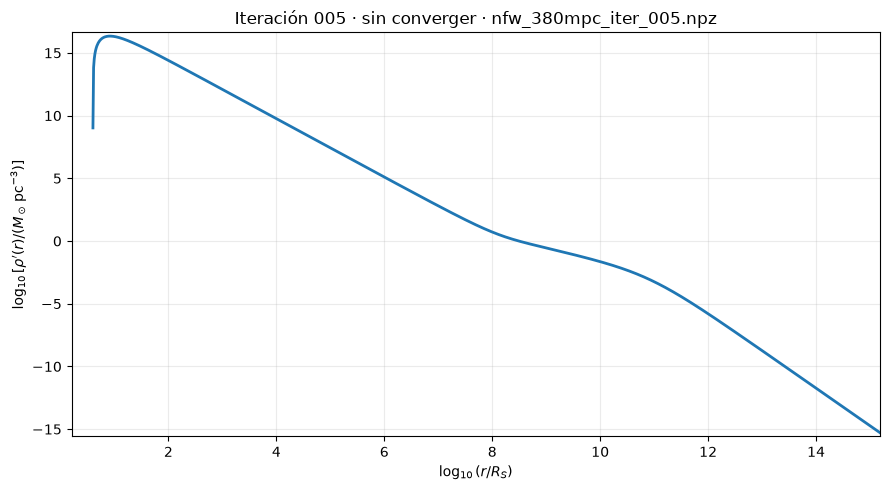

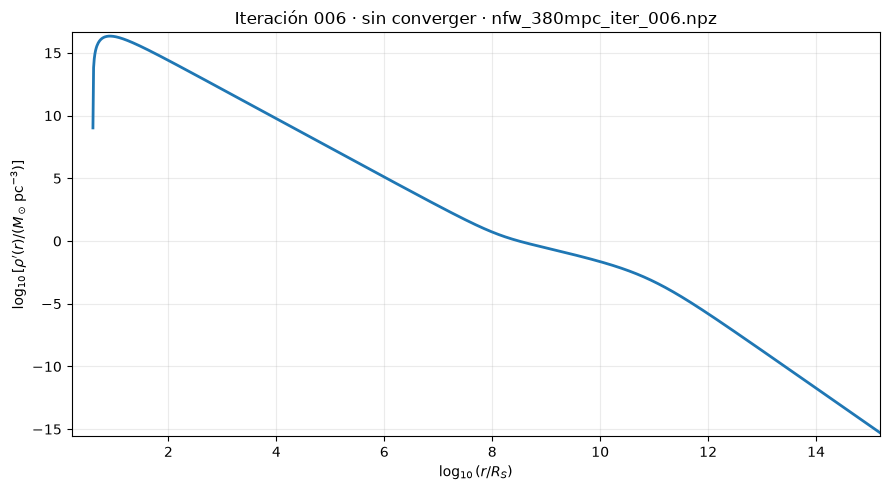

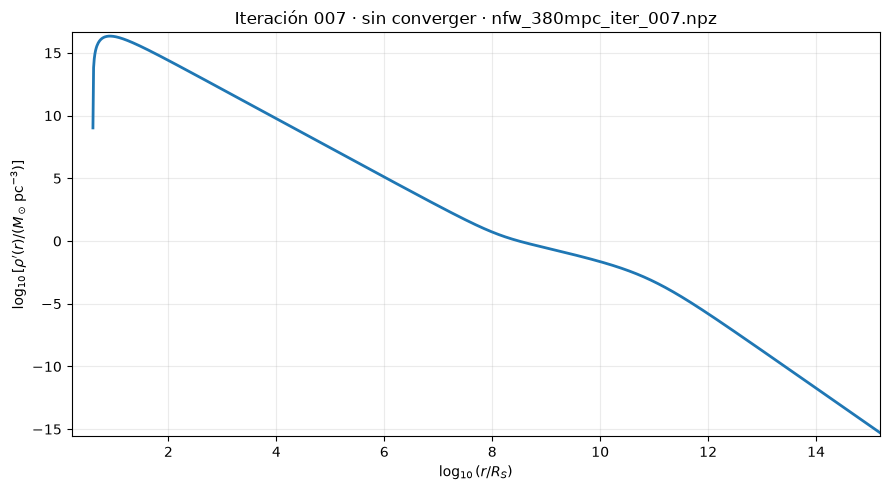

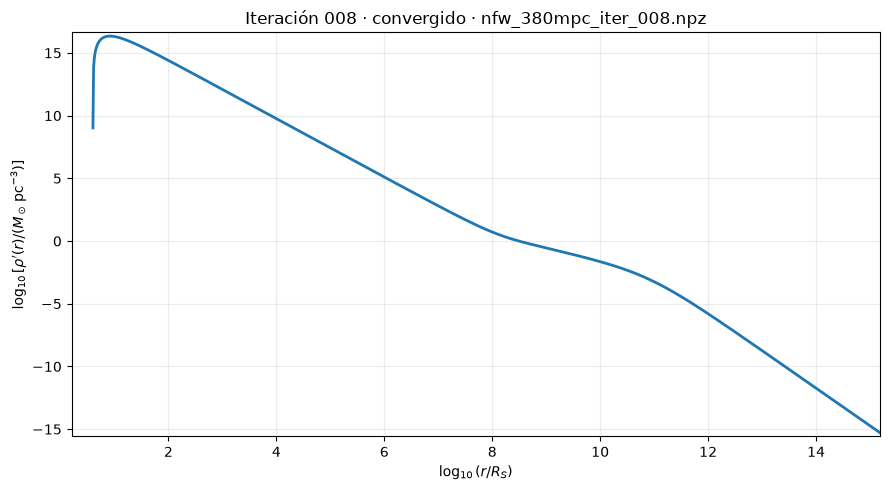

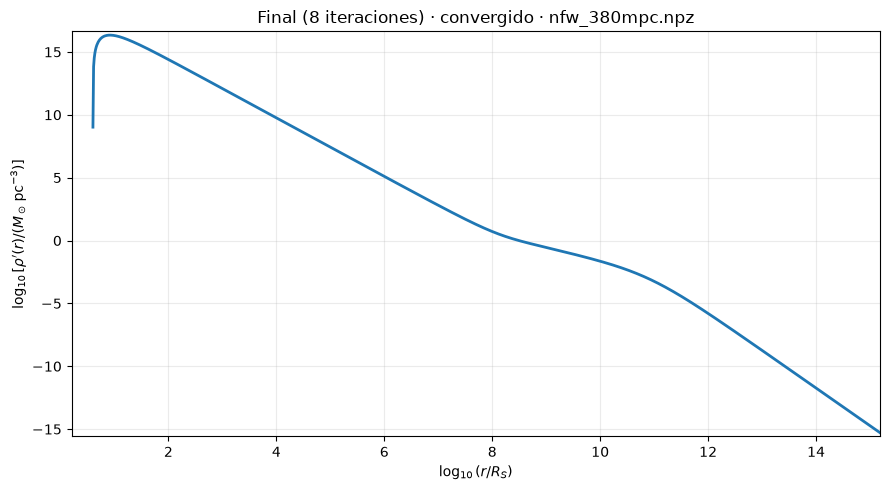

In [2]:
for rec in records:
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(np.log10(rec['radii'] / R_S), np.log10(rec['density']), linewidth=2)
    status = 'convergido' if rec['converged'] else 'sin converger'
    format_axes(ax, f"{rec['label']} · {status} · {rec['path'].name}")
    fig.tight_layout()
    plt.show()

## Todos los resultados superpuestos

El recuadro inferior izquierdo amplía $7.9\leq\log_{10}(r/R_S)\leq8$ con las mismas curvas y estilos que el gráfico principal.

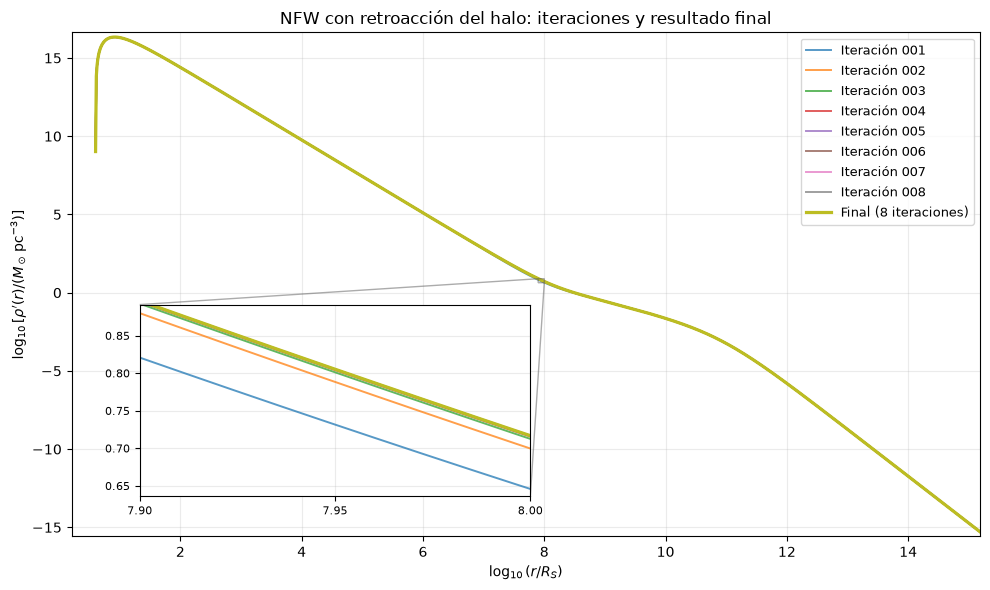

In [3]:
fig, ax = plt.subplots(figsize=(10, 6))
for rec in records:
    ax.plot(np.log10(rec['radii'] / R_S), np.log10(rec['density']), label=rec['label'],
            linewidth=2.3 if rec['is_final'] else 1.4,
            alpha=1 if rec['is_final'] else 0.75)
format_axes(ax, 'NFW con retroacción del halo: iteraciones y resultado final')
add_profile_zoom(ax)
ax.legend(loc='best', fontsize=9)
fig.tight_layout()
plt.show()

## Comparación con el perfil analítico final para $\gamma=1$

La configuración de los NPZ conserva los parámetros de `dm_spikes_execution3.py`: $M_{\rm BH}$, $\rho_s$, $r_s$ y $c$. Para la ley de potencia se toman $r_0=r_s$ y $\rho_0=\rho_s$, de modo que $\rho_{\rm inicial}^{\rm PL}(r)=\rho_s(r/r_s)^{-1}$ coincide con la **normalización asintótica interior** del NFW. El perfil final se calcula con `cusp_profile` y se dibuja solamente entre $4.0001R_S$ y su propio $R_{\rm sp}$, incluido el extremo.

El recuadro inferior izquierdo amplía $7.9\leq\log_{10}(r/R_S)\leq8$ con las mismas curvas y estilos que el gráfico principal.

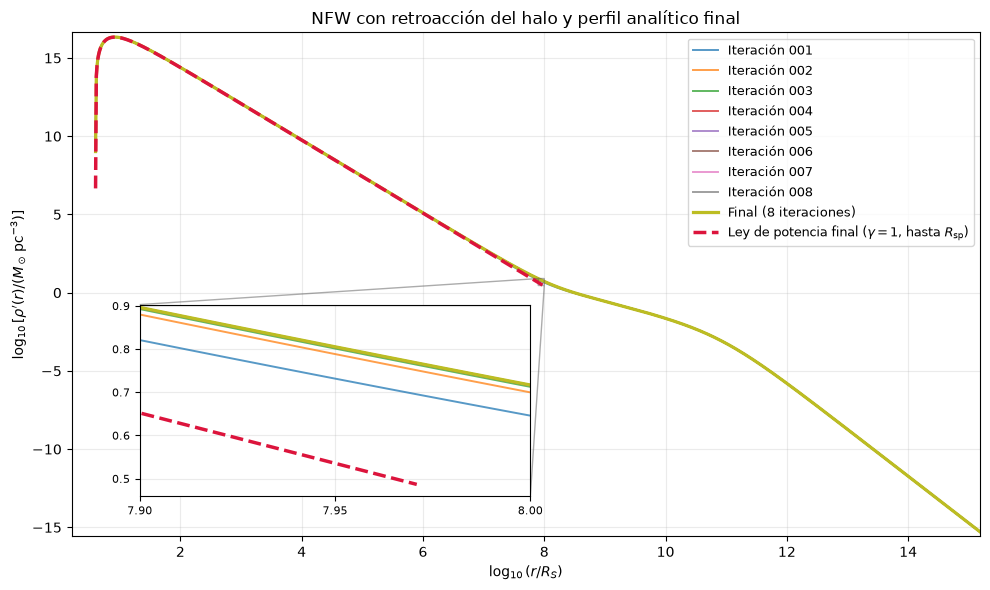

R_S = 2.48841e-07 pc; R_sp = 23.2725 pc; normalización: rho_s = 0.003568 Msun/pc³, r_s = 20000 pc


In [4]:
for rec in records:
    config = rec['config']
    if (config['M_bh'] != reference['M_bh']
            or config['clight'] != reference['clight']
            or config['density'] != reference['density']):
        raise ValueError(f"Normalización distinta en {rec['path'].name}")

gamma = 1.0
M_bh = reference['M_bh']
rho_s = reference['density']['parameters']['rho_s']
r_s = reference['density']['parameters']['r_s']
R_sp = spike_radius(M_bh, gamma, rho_s, r_s)
r_power_law = np.geomspace(4.0001 * R_S, R_sp, 600)
rho_power_law = cusp_profile(r_power_law, M_bh, gamma, R_S,
                                r0=r_s, rho0=rho_s)

fig, ax = plt.subplots(figsize=(10, 6))
for rec in records:
    ax.plot(np.log10(rec['radii'] / R_S), np.log10(rec['density']), label=rec['label'],
            linewidth=2.3 if rec['is_final'] else 1.4,
            alpha=1 if rec['is_final'] else 0.75)
ax.plot(np.log10(r_power_law / R_S), np.log10(rho_power_law), color='crimson', linestyle='--',
        linewidth=2.5, label=r'Ley de potencia final ($\gamma=1$, hasta $R_{\rm sp}$)',
        zorder=10)
format_axes(ax, 'NFW con retroacción del halo y perfil analítico final')
add_profile_zoom(ax)
ax.legend(loc='best', fontsize=9)
fig.tight_layout()
plt.show()
print(f'R_S = {R_S:.6g} pc; R_sp = {R_sp:.6g} pc; '
      f'normalización: rho_s = {rho_s:g} Msun/pc³, r_s = {r_s:g} pc')

## Perfil convergido y pendiente logarítmica local

El panel superior representa la densidad en coordenadas logarítmicas. El inferior muestra $\gamma_{\mathrm{eff}}(r)=-d\ln\rho^\prime/d\ln r$, calculada por diferencias centradas en $\ln r$. Se omiten veinte puntos en cada extremo del panel de pendientes. La línea vertical discontinua marca $\log_{10}(R_{\rm sp}/R_S)$ para la ley de potencia de $\gamma=1$ calculada con spike_radius.

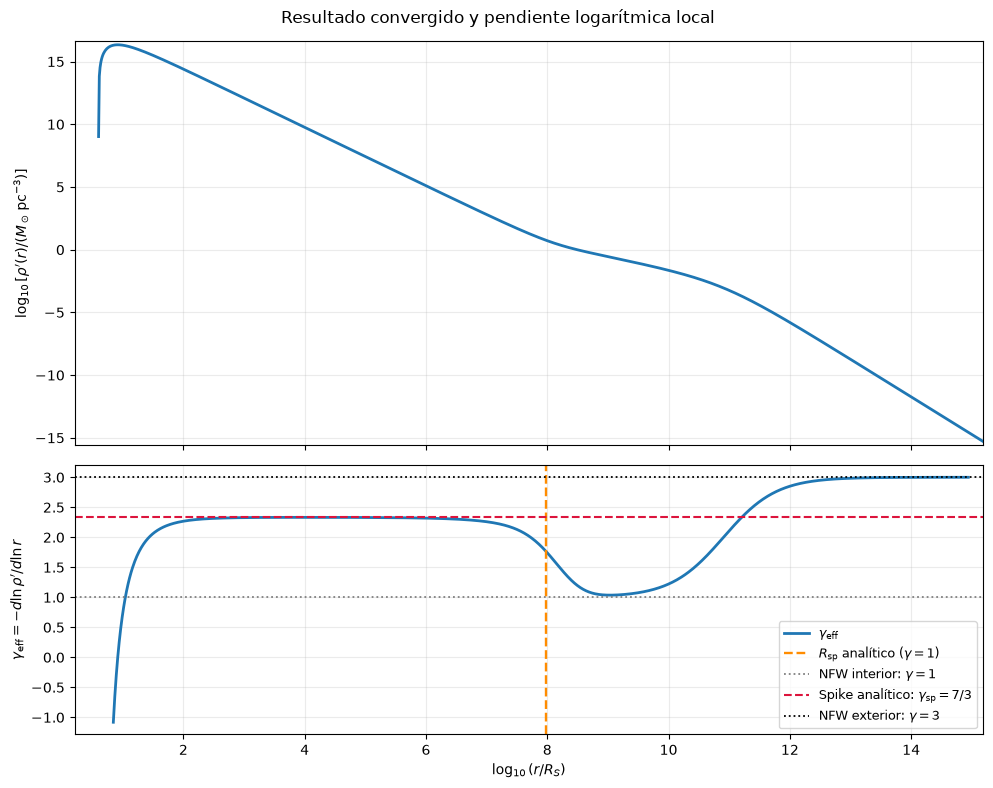

In [5]:
converged_record = next(rec for rec in records if rec['is_final'] and rec['converged'])
r_converged = converged_record['radii']
rho_converged = converged_record['density']
x_converged = np.log10(r_converged / R_S)
y_converged = np.log10(rho_converged)
gamma_eff = -np.gradient(np.log(rho_converged), np.log(r_converged))

trim = 20
fig, (ax_profile, ax_slope) = plt.subplots(
    2, 1, figsize=(10, 8), sharex=True, gridspec_kw={'height_ratios': [3, 2]}
)
ax_profile.plot(x_converged, y_converged, color='tab:blue', linewidth=2)
ax_profile.set_ylabel(r'$\log_{10}[\rho^\prime(r)/(M_\odot\,\mathrm{pc}^{-3})]$')
ax_profile.set_ylim(np.log10(rho_min / 2), np.log10(rho_max * 2))
ax_profile.grid(True, alpha=0.25)

ax_slope.plot(x_converged[trim:-trim], gamma_eff[trim:-trim],
              color='tab:blue', linewidth=2, label=r'$\gamma_{\mathrm{eff}}$')
ax_slope.axvline(np.log10(R_sp / R_S), color='darkorange',
                 linestyle='--', linewidth=1.7,
                 label=r'$R_{\rm sp}$ analítico ($\gamma=1$)')
ax_slope.axhline(1.0, color='gray', linestyle=':', linewidth=1.3,
                 label=r'NFW interior: $\gamma=1$')
ax_slope.axhline(gamma_spike(1.0), color='crimson', linestyle='--',
                 linewidth=1.5, label=r'Spike analítico: $\gamma_{\rm sp}=7/3$')
ax_slope.axhline(3.0, color='black', linestyle=':', linewidth=1.3,
                 label=r'NFW exterior: $\gamma=3$')
ax_slope.set(xlim=(reference_x_left, np.log10(r_max / R_S)),
             xlabel=r'$\log_{10}(r/R_S)$',
             ylabel=r'$\gamma_{\mathrm{eff}}=-d\ln\rho^\prime/d\ln r$')
ax_slope.grid(True, alpha=0.25)
ax_slope.legend(loc='best', fontsize=9)
fig.suptitle('Resultado convergido y pendiente logarítmica local')
fig.tight_layout()
plt.show()

## Cambio relativo entre iteraciones consecutivas

Para cada iteración $k=1,\ldots,8$ guardada en `results/NFW_test_1200`, se representa $|\rho_k^\prime(r)-\rho_{k-1}^\prime(r)|/\rho_{k-1}^\prime(r)$. La iteración $k=0$ es el perfil inicial calculado con los parámetros de `config_json`. El archivo final reproduce la última iteración y no se cuenta dos veces. La escala vertical `symlog` permite apreciar los cambios de varios órdenes de magnitud. La línea horizontal discontinua marca la tolerancia relativa de convergencia $10^{-4}$, aplicada al máximo del cambio sobre todos los radios.

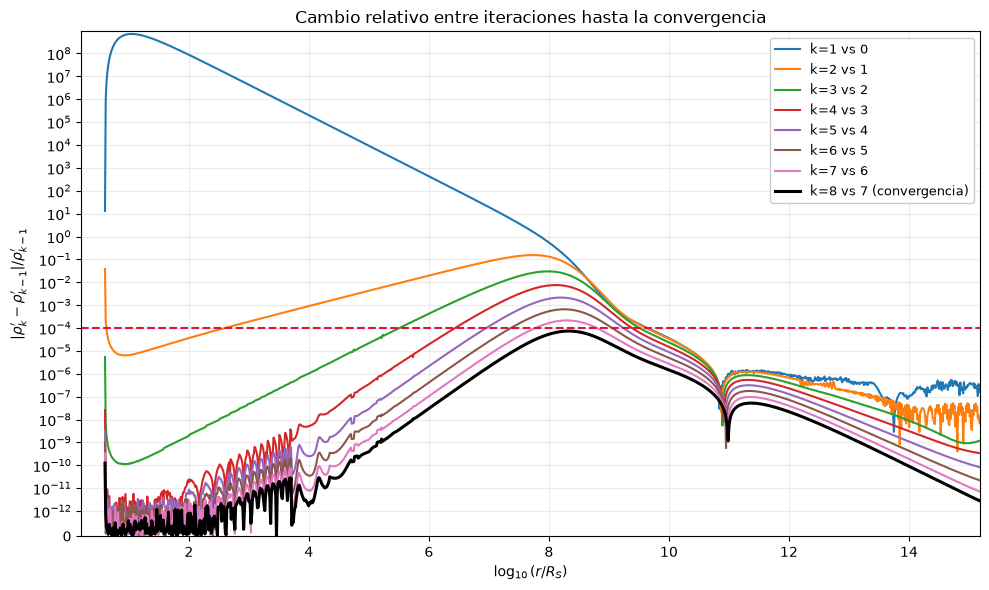

In [6]:
iteration_records = sorted(
    (rec for rec in records if not rec['is_final']),
    key=lambda rec: rec['iteration'],
)
if not iteration_records or [rec['iteration'] for rec in iteration_records] != list(
    range(1, converged_record['iteration'] + 1)
):
    raise ValueError('Faltan iteraciones para calcular cambios consecutivos hasta la convergencia.')
if not iteration_records[-1]['converged']:
    raise ValueError('La última iteración guardada no figura como convergida.')
if not np.allclose(iteration_records[-1]['density'], rho_converged, rtol=1e-12, atol=0):
    raise ValueError('El resultado final difiere de la última iteración guardada.')

initial_density = nfw(**reference['density']['parameters'])(iteration_records[0]['radii'])
previous_density = initial_density  # k=0: perfil analítico inicial usado por el solver.
max_error = 0.0
fig, ax = plt.subplots(figsize=(10, 6))
for rec in iteration_records:
    if not np.array_equal(rec['radii'], iteration_records[0]['radii']):
        raise ValueError(f"Malla radial distinta en {rec['path'].name}")
    if not np.all(np.isfinite(previous_density)) or np.any(previous_density <= 0):
        raise ValueError('La densidad anterior debe ser positiva y finita.')
    k = rec['iteration']
    relative_change = np.abs(rec['density'] / previous_density - 1.0)
    max_error = max(max_error, float(np.max(relative_change)))
    is_last = k == iteration_records[-1]['iteration']
    ax.plot(np.log10(rec['radii'] / R_S), relative_change,
            color='black' if is_last else None,
            linewidth=2.2 if is_last else 1.5,
            label=f'k={k} vs {k - 1}' + (' (convergencia)' if is_last else ''))
    previous_density = rec['density']

ax.set(xlim=(reference_x_left, np.log10(r_max / R_S)),
       ylim=(0, max_error * 1.3),
       xlabel=r'$\log_{10}(r/R_S)$',
       ylabel=r'$|\rho_k^\prime-\rho_{k-1}^\prime|/\rho_{k-1}^\prime$',
       title='Cambio relativo entre iteraciones hasta la convergencia')
ax.set_yscale('symlog', linthresh=1e-12)
ax.axhline(reference['solver']['rtol'], color='crimson', linestyle='--', linewidth=1.5)
ax.grid(True, alpha=0.25)
ax.legend(loc='upper right', fontsize=9, framealpha=1.0)
fig.tight_layout()
plt.show()


## Resultado convergido y perfiles iniciales y finales

El NFW inicial se evalúa con los parámetros $\rho_s$ y $r_s$ guardados en la configuración de los resultados. Las leyes de potencia inicial y final usan $\gamma=1$, $\rho_0=\rho_s$ y $r_0=r_s$. Ambas se dibujan hasta el mismo $R_{\rm sp}$. La ley de potencia inicial aparece con cruces verdes sin línea para mantener visible el NFW inicial.

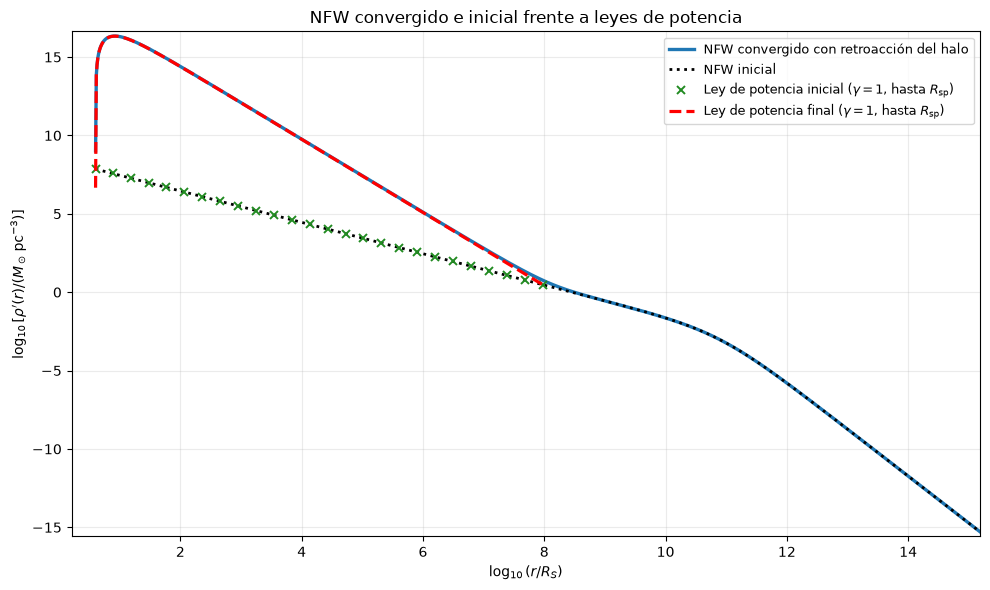

In [7]:
rho_nfw_initial = nfw(**reference['density']['parameters'])(r_converged)
rho_power_law_initial = power_law(rho0=rho_s, r0=r_s, gamma=gamma)(r_power_law)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x_converged, y_converged, color='tab:blue', linewidth=2.4,
        label='NFW convergido con retroacción del halo')
ax.plot(x_converged, np.log10(rho_nfw_initial), color='black',
        linestyle=':', linewidth=2.0, label='NFW inicial')
ax.plot(np.log10(r_power_law / R_S), np.log10(rho_power_law_initial),
        color='forestgreen', linestyle='None', marker='x', markersize=6,
        markeredgewidth=1.4,
        markevery=np.linspace(0, len(r_power_law) - 1, 26, dtype=int),
        label=r'Ley de potencia inicial ($\gamma=1$, hasta $R_{\rm sp}$)')
ax.plot(np.log10(r_power_law / R_S), np.log10(rho_power_law),
        color='red', linestyle='--', linewidth=2.3,
        label=r'Ley de potencia final ($\gamma=1$, hasta $R_{\rm sp}$)')

format_axes(ax, 'NFW convergido e inicial frente a leyes de potencia')
ax.legend(loc='best', fontsize=9)
fig.tight_layout()
plt.show()